In [1]:
from google.colab import files
uploaded=files.upload()

Saving healthcare_dataset (1).csv to healthcare_dataset (1).csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv("healthcare_dataset (1).csv")

In [ ]:
df["Medical_Code_Category"] = df["Medical_Code"].str.replace("ICD-10-", "")

In [5]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [7]:
df.describe()

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [9]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [10]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [11]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Year_Month'] = df['Date of Admission'].dt.to_period('M')

In [12]:
monthly_admissions = df.groupby('Year_Month').size()

In [13]:
monthly_admissions.head()

,0
Year_Month,
2019-05,686
2019-06,907
2019-07,957
2019-08,1001
2019-09,936


In [14]:
peak_month = monthly_admissions.idxmax()
peak_admissions = monthly_admissions.max()

In [15]:
print("Peak Admission Month:", peak_month)
print("Number of Admissions:", peak_admissions)

Peak Admission Month: 2020-08
Number of Admissions: 1014


In [16]:
billing_data = df.groupby(
    ['Medical Condition', 'Insurance Provider']
)['Billing Amount'].sum().unstack(fill_value=0)

<Axes: xlabel='Medical Condition'>

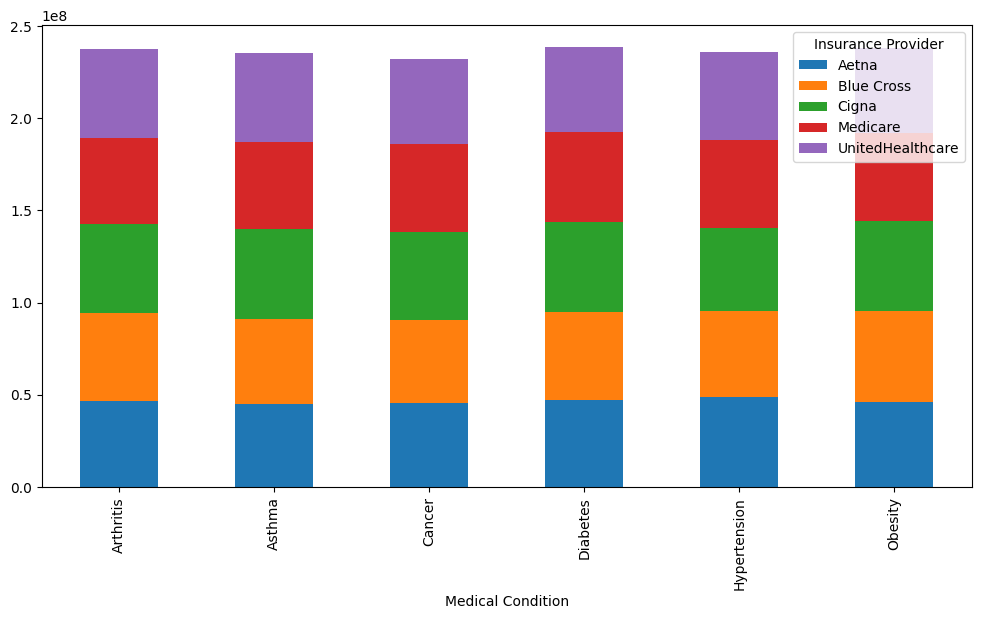

In [17]:
billing_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)


/tmp/ipykernel_3217/3738407951.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Insurance Provider')


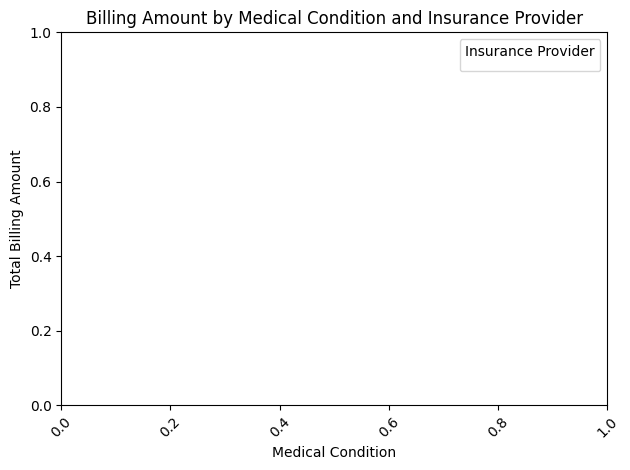

In [18]:
plt.title('Billing Amount by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.tight_layout()
plt.show()

<Axes: xlabel='Medical Condition', ylabel='Billing Amount'>

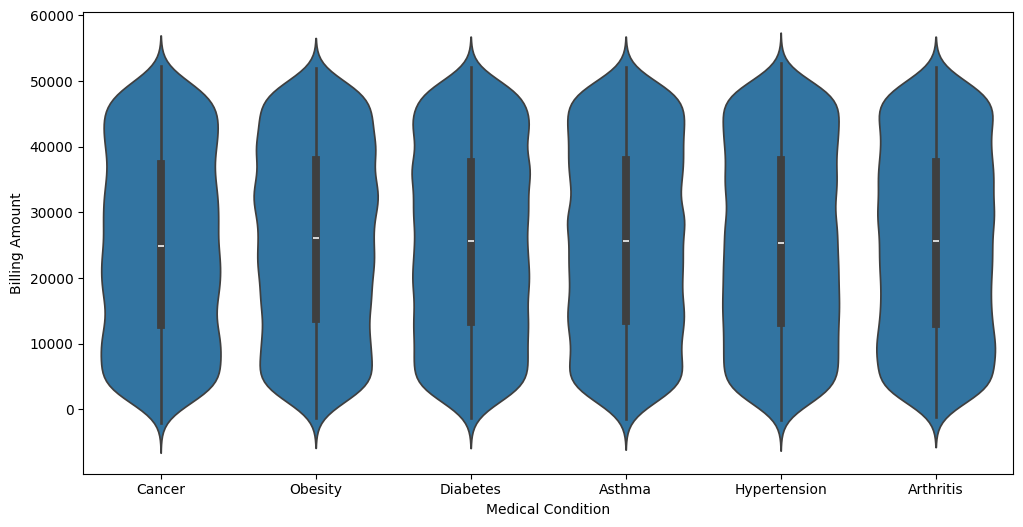

In [19]:
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

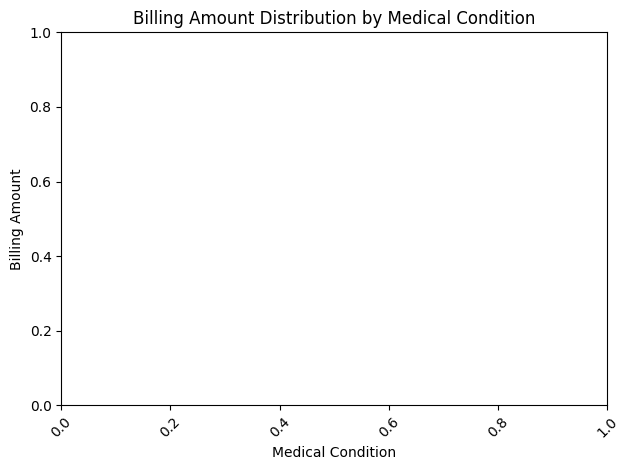

In [20]:
plt.title('Billing Amount Distribution by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Insurance Provider', ylabel='Billing Amount'>

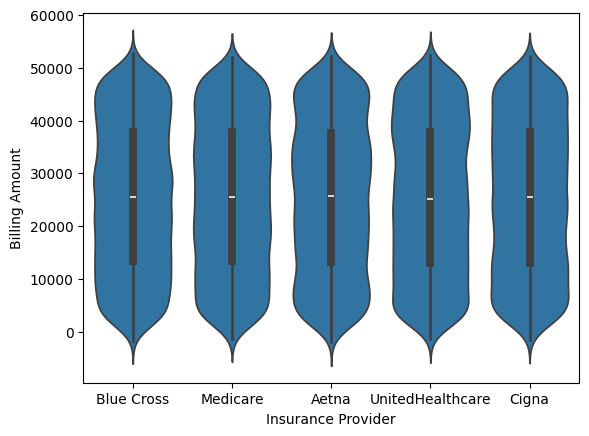

In [22]:
sns.violinplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount'
)

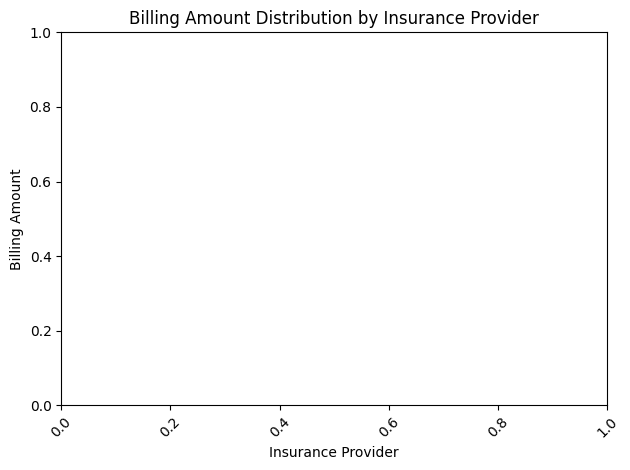

In [23]:
plt.title('Billing Amount Distribution by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
print("Average Billing Amount by Medical Condition:")
print(df.groupby('Medical Condition')['Billing Amount'].mean())

Average Billing Amount by Medical Condition:
Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64


In [25]:
print("\nAverage Billing Amount by Insurance Provider:")
print(df.groupby('Insurance Provider')['Billing Amount'].mean())


Average Billing Amount by Insurance Provider:
Insurance Provider
Aetna               25553.294506
Blue Cross          25613.011503
Cigna               25525.766314
Medicare            25615.990508
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64


In [26]:
df ['Admission Month']=df['Date of Admission'].dt.month
df['Admission Month']

,Admission Month
0,1
1,8
2,9
3,11
4,9
...,...
55495,8
55496,1
55497,7
55498,5


In [27]:
monthly_admissions = df.groupby('Admission Month').size()
monthly_admissions

,0
Admission Month,
1,4692
2,4255
3,4672
4,4518
5,4599
6,4699
7,4812
8,4832
9,4546


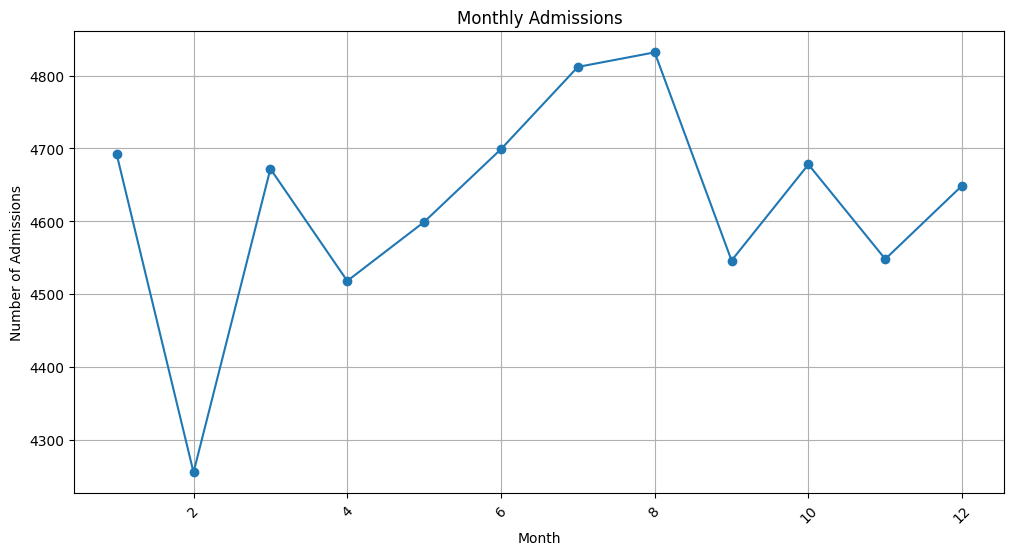

In [28]:
plt.figure(figsize=(12, 6))
monthly_admissions.plot(kind="line",marker="o")
plt.title('Monthly Admissions')
plt.xlabel('Month')
plt.ylabel('Number of Admissions')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [29]:
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Stay Duration'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
correlation_matrix = df[["Age", "Stay Duration", "Billing Amount"]].corr()
correlation_matrix

,Age,Stay Duration,Billing Amount
Age,1.000000,0.008220,-0.003832
Stay Duration,0.008220,1.000000,-0.005602
Billing Amount,-0.003832,-0.005602,1.000000


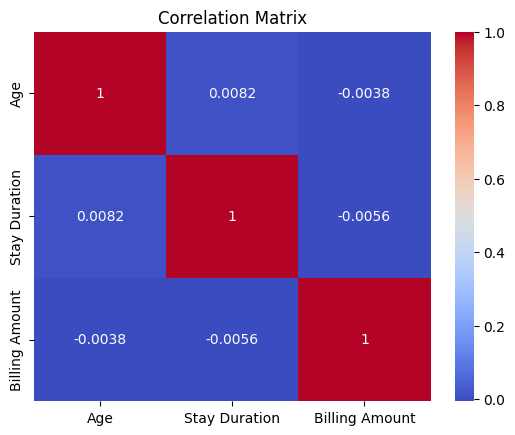

In [30]:
sns.heatmap(correlation_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()